# Orange County Analysis

In [48]:
# Import statements
import pandas as pd

from utils import (
    load_census,
    add_standardized_race,
    census_rollup,
    policing_summary_table,
    compute_prosecution_rates,
    merge_policing_with_prosecution,
    add_disparity_metrics,
    visualization_setup,
    visualize
)

# Display all columns
pd.set_option('display.max_columns', None)

# Import Data

In [49]:
# Load in policing data
policing = pd.read_csv("../data/cleaned/cleaned_orange_ripa_2019_2023.csv")

<positron-console-cell-49>:2: DtypeWarning: Columns (0: time_of_stop, 1: school_code, 2: school_name, 3: ros_warning_cds, 4: ros_citation_cds, 5: ros_in_field_cite_release_cds, 6: ros_custodial_wout_warrant_cds) have mixed types. Specify dtype option on import or set low_memory=False.


In [50]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/cleaned/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['Year'] = prosecution['filed_date'].dt.year

In [51]:
# Load in census data
census = load_census("06059")

# Policing Analysis

In [52]:
# Filter for only discretionary stops
policing = policing[policing["reason_for_stop"].isin([1, 2])]

# Add standardized race column to match policing and prosecution labels
policing = add_standardized_race(policing, "race_ethnicity")

# Roll-up census data to be more coarse to match policing/prosecution race categories
census_coarse = census_rollup(census)

# Adds counts, rates, and per-capita rates for stops, searches, and hits
policing_analysis = policing_summary_table(policing, census_coarse)

policing_analysis

,Year,Perceived Race,Stop Count,Search Count,Hit Count,Search Rate,Hit Rate,Population,"Stops per 1,000","Searches per 1,000","Hits per 1,000"
0,2019,Asian,3001,111,53,0.036988,0.477477,699124,4.292515,0.158770,0.075809
1,2019,Black/African American,1785,257,102,0.143978,0.396887,49304,36.203959,5.212559,2.068798
2,2019,Hispanic/Latino,14412,2047,806,0.142034,0.393747,1086834,13.260535,1.883452,0.741604
3,2019,Other,3613,116,46,0.032106,0.396552,153072,23.603272,0.757813,0.300512
4,2019,White,23042,2480,1160,0.107630,0.467742,1198655,19.223213,2.068986,0.967751
5,2020,Asian,2356,123,54,0.052207,0.439024,699124,3.369932,0.175934,0.077240
6,2020,Black/African American,1381,217,108,0.157133,0.497696,49304,28.009898,4.401266,2.190492
7,2020,Hispanic/Latino,11782,2023,885,0.171703,0.437469,1086834,10.840662,1.861370,0.814292
8,2020,Other,2632,135,56,0.051292,0.414815,153072,17.194523,0.881938,0.365841
9,2020,White,16917,1955,1015,0.115564,0.519182,1198655,14.113319,1.630995,0.846782


## Prosecution Rates

In [53]:
# Standardize race labels to match with policing data
prosecution = add_standardized_race(prosecution, "canonical_race")

prosecution_analysis = compute_prosecution_rates(
    prosecution,
    convicted_col="was_convicted",
    enhancement_col="is_enhancement_charge"
)

prosecution_analysis

,Canonical Race,Year,Total Prosecution Cases,Prosecution Rate,Enhancement Rate
0,Asian,2021,4578,0.706204,0.107907
1,Asian,2022,4228,0.721618,0.099811
2,Asian,2023,3002,0.751499,0.081945
3,Black/African American,2021,5256,0.729333,0.075152
4,Black/African American,2022,6609,0.730519,0.064458
5,Black/African American,2023,3312,0.666667,0.045592
6,Hispanic/Latino,2021,50505,0.771801,0.092506
7,Hispanic/Latino,2022,54526,0.771646,0.083556
8,Hispanic/Latino,2023,27383,0.744294,0.076142
9,Other,2021,4653,0.617021,0.146357


# Disparity Ratios

In [57]:
# Merge policing and prosecution data into one table based on common policing race label
analysis = merge_policing_with_prosecution(policing_analysis, prosecution_analysis)

# Add White-normalized ratios
analysis = add_disparity_metrics(analysis)

analysis

,Year,Race,Stop Count,Search Count,Hit Count,Search Rate,Hit Rate,Population,"Stops per 1,000","Searches per 1,000","Hits per 1,000",Total Prosecution Cases,Prosecution Rate,Enhancement Rate,"Stops per 1,000 (White=1)","Searches per 1,000 (White=1)",Search Rate (White=1),Hit Rate (White=1),Prosecution Rate (White=1),Enhancement Rate (White=1)
0,2019,Asian,3001,111,53,0.036988,0.477477,699124,4.292515,0.158770,0.075809,NaN,NaN,NaN,0.223299,0.076738,0.343657,1.020814,NaN,NaN
1,2019,Black/African American,1785,257,102,0.143978,0.396887,49304,36.203959,5.212559,2.068798,NaN,NaN,NaN,1.883346,2.519379,1.337714,0.848517,NaN,NaN
2,2019,Hispanic/Latino,14412,2047,806,0.142034,0.393747,1086834,13.260535,1.883452,0.741604,NaN,NaN,NaN,0.689819,0.910326,1.319660,0.841804,NaN,NaN
3,2019,Other,3613,116,46,0.032106,0.396552,153072,23.603272,0.757813,0.300512,NaN,NaN,NaN,1.227853,0.366273,0.298304,0.847800,NaN,NaN
4,2019,White,23042,2480,1160,0.107630,0.467742,1198655,19.223213,2.068986,0.967751,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN
5,2020,Asian,2356,123,54,0.052207,0.439024,699124,3.369932,0.175934,0.077240,NaN,NaN,NaN,0.238777,0.107869,0.451759,0.845609,NaN,NaN
6,2020,Black/African American,1381,217,108,0.157133,0.497696,49304,28.009898,4.401266,2.190492,NaN,NaN,NaN,1.984643,2.698516,1.359699,0.958616,NaN,NaN
7,2020,Hispanic/Latino,11782,2023,885,0.171703,0.437469,1086834,10.840662,1.861370,0.814292,NaN,NaN,NaN,0.768116,1.141248,1.485776,0.842613,NaN,NaN
8,2020,Other,2632,135,56,0.051292,0.414815,153072,17.194523,0.881938,0.365841,NaN,NaN,NaN,1.218319,0.540736,0.443838,0.798978,NaN,NaN
9,2020,White,16917,1955,1015,0.115564,0.519182,1198655,14.113319,1.630995,0.846782,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN


# Visualizations

### Outcome Tests
1. **Hit Rate** (hits / searches): Conditional on being searched, how often is contraband found?
2. **Conviction Rate** (convictions / cases): Conditional on charges being filed, how often does the case result in conviction?
3. **Enhancement Rate** (enhancements / cases): Conditional on a case existing, how often are sentence-enhancing charges applied?

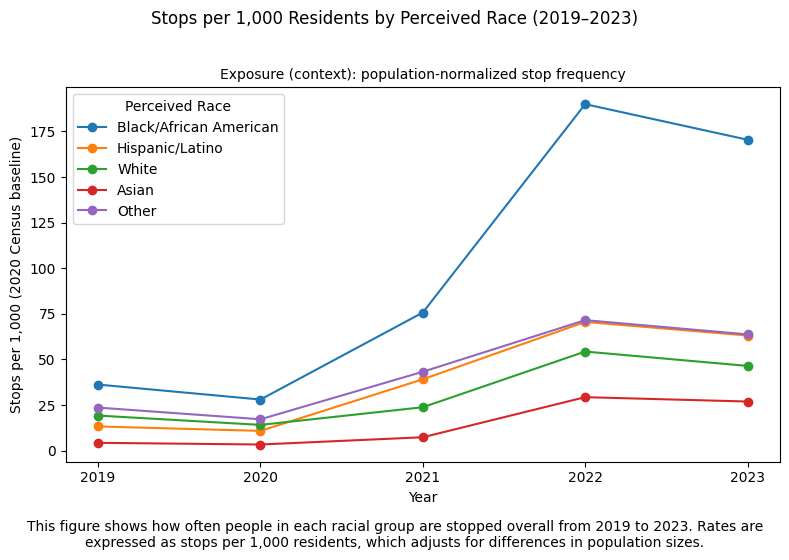

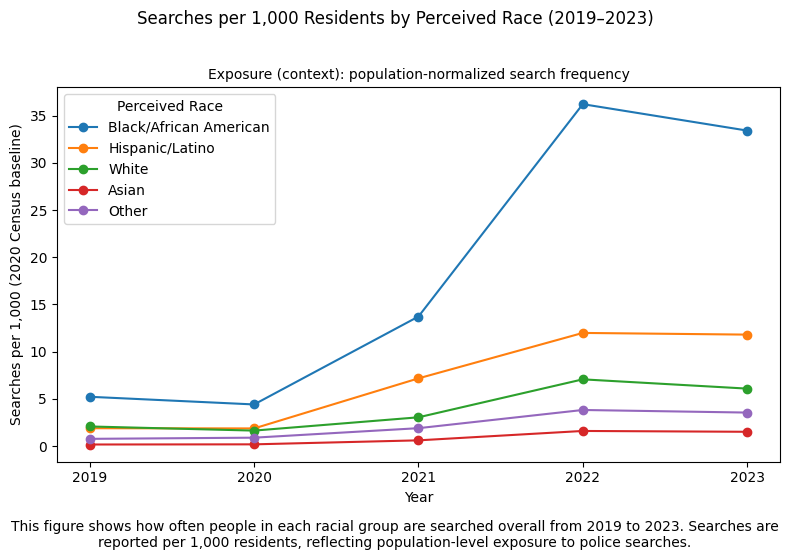

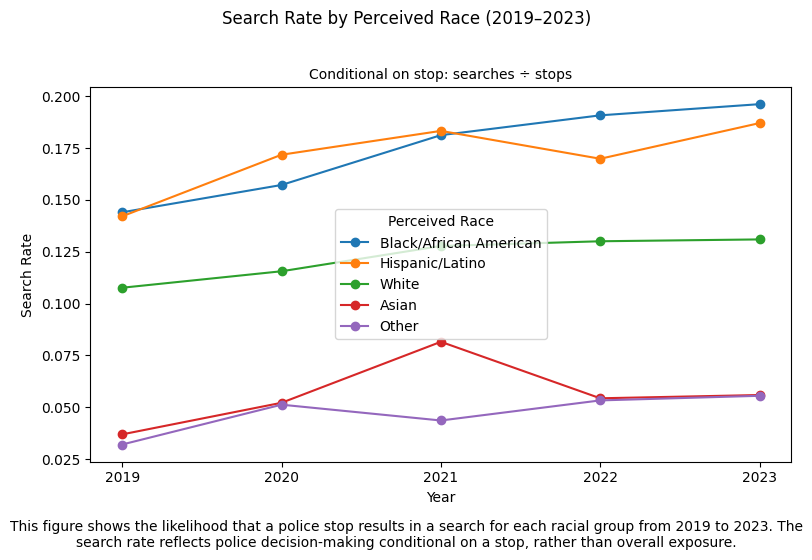

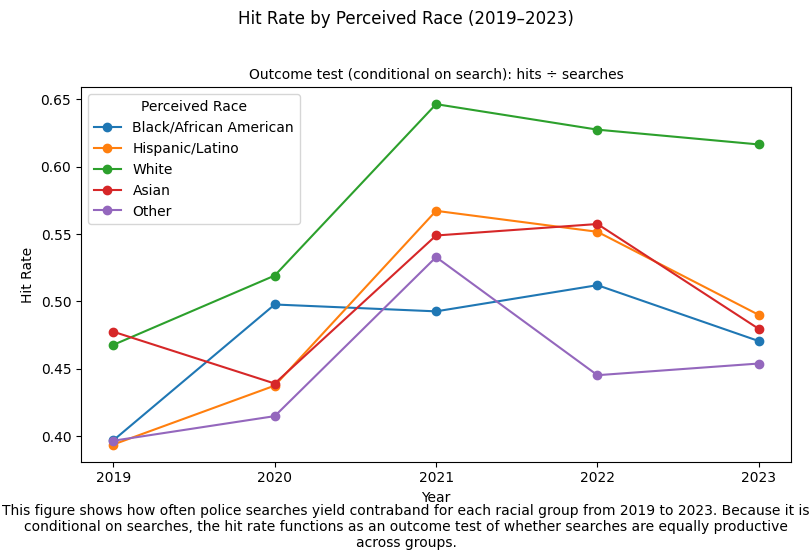

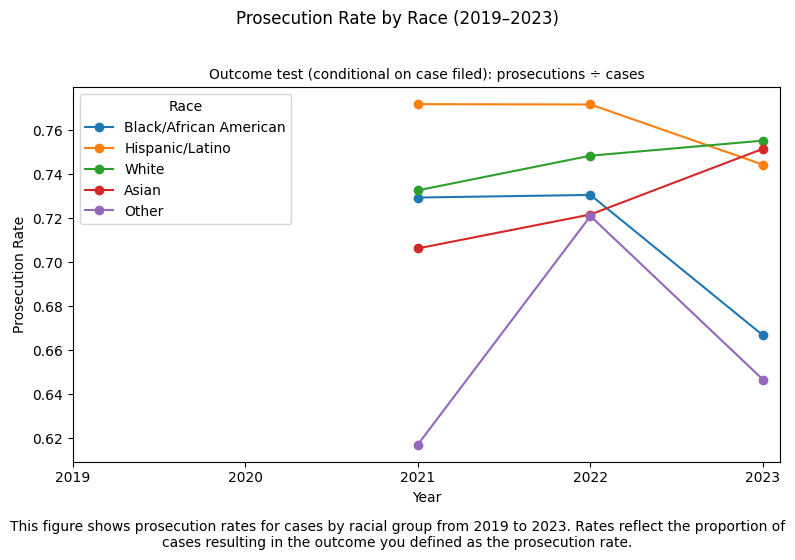

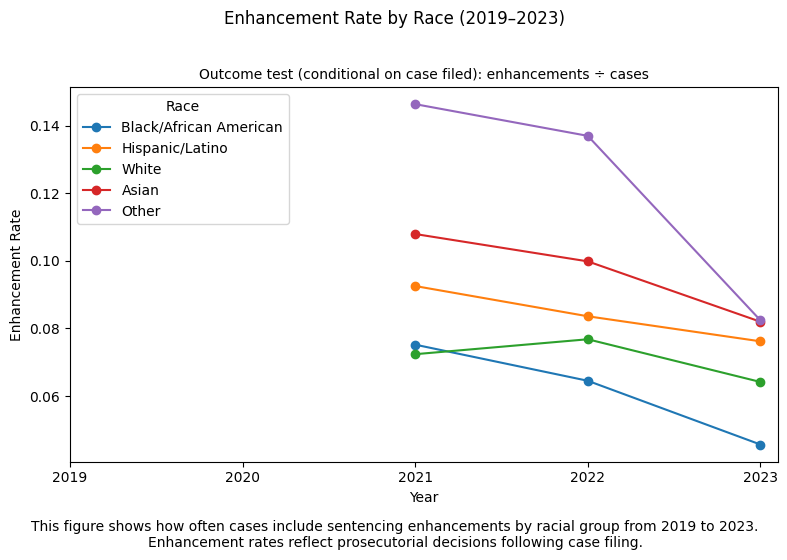

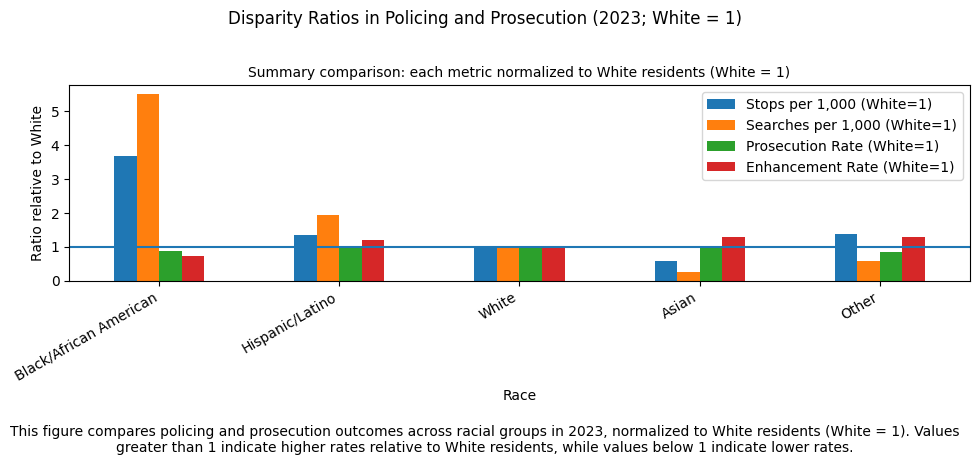

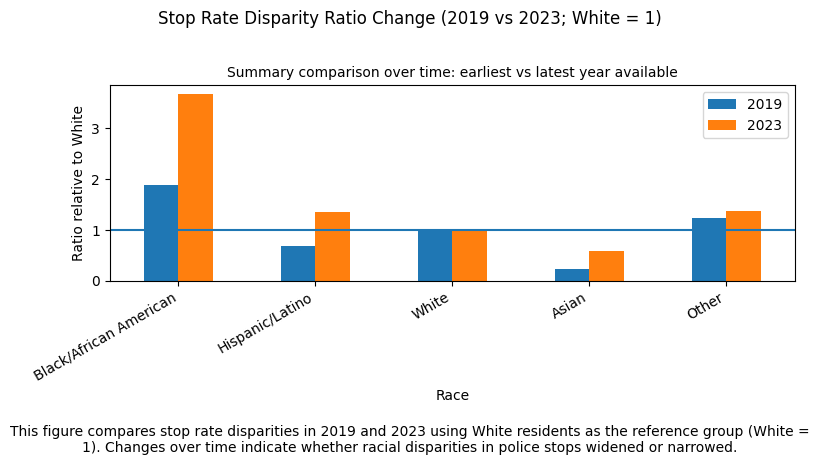

In [59]:
# Keep plots consistent across runs
analysis = visualization_setup(analysis)

visualize(analysis)